<div style="
    background: linear-gradient(135deg, #141E30, #243B55);
    padding: 35px;
    border-radius: 18px;
    text-align: center;
    color: white;
">

<h1>🛒 Advanced Python Sales Analysis</h1>

<h3 style="color:#64FFDA;">
Data Exploration, Cleaning & Automated Reporting
</h3>

<p>
Python • Pandas • NumPy • Matplotlib • Seaborn
</p>

</div>

<div style="
    background: linear-gradient(90deg, #00695C, #26A69A);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
📂 1. Data Loading & Understanding
</h2>

</div>

In [104]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
# Load the Sales Data worksheet from the Excel file
Data = pd.read_excel('Sales_Data.xlsx',sheet_name='Sales Data')

In [106]:
# Display the first five rows
Data.head()

,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
0,CA-2016-152156,2020.0,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.0,523.9200,157.17600,314.35200,209.56800
1,CA-2016-152156,2020.0,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.0,2195.8200,402.56700,1207.70100,988.11900
2,CA-2016-138688,2020.0,Jun,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.0,29.2400,8.77200,17.54400,11.69600
3,US-2015-108966,2020.0,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.0,4787.8875,478.78875,2393.94375,2393.94375
4,US-2015-108966,2020.0,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.0,35.7888,11.18400,22.36800,13.42080


In [107]:
# Display column names, data types, and non-null values
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order ID                  1013 non-null   str           
 1   Year                      1013 non-null   float64       
 2   Month                     1013 non-null   str           
 3   Order Date                1011 non-null   datetime64[us]
 4   Ship Date                 1013 non-null   datetime64[us]
 5   Ship Mode                 1008 non-null   str           
 6   Customer ID               1013 non-null   str           
 7   Customer Name             1009 non-null   str           
 8   Client Segment            1013 non-null   str           
 9   Country                   1013 non-null   str           
 10  State                     1013 non-null   str           
 11  Postal Code               1010 non-null   float64       
 12  Region                    1013 

In [108]:
# Check the number of rows and columns
Data.shape

(1014, 24)

In [109]:
# Generate descriptive statistics for numerical columns
Data.describe().T

,count,mean,min,25%,50%,75%,max,std
Year,1013.0,2015.78381,2014.0,2015.0,2016.0,2017.0,2020.0,1.290607
Order Date,1011,2016-04-03 07:27:14.421365,2014-01-04 00:00:00,2015-04-21 12:00:00,2016-05-30 00:00:00,2017-04-07 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,1013,2016-04-08 02:16:27.956564,2014-01-08 00:00:00,2015-04-28 00:00:00,2016-06-04 00:00:00,2017-04-11 00:00:00,2018-01-05 00:00:00,NaN
Postal Code,1010.0,53763.745545,1841.0,19805.0,53132.0,85254.0,98661.0,31673.440511
Sales Price,1005.0,237.835866,1.08,18.392,55.5,208.56,8159.952,595.738879
Quantity,1013.0,3.810464,1.0,2.0,3.0,5.0,14.0,2.269755
Discount,1013.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Total Sales Amount,1013.0,1109.305256,1.68,44.7936,163.44,732.1088,65279.616,3648.500604
Purchasing Price,1013.0,143.390153,0.648,11.0976,33.288,121.47,5303.9688,358.969712
Total Purchasing Amounts,1013.0,719.116463,0.924,29.472,113.568,480.4,42431.7504,2274.609212


<div style="
    background: linear-gradient(90deg, #6A1B9A, #AB47BC);
    padding: 16px 22px;
    border-radius: 10px;
    color: white;
">

<h2 style="margin:0;">
🧹 2. Data Cleaning & Preprocessing
</h2>

</div>

In [110]:
# Create a working copy and preserve the original dataset
Clean_Data = Data.copy()
print("Original Data", Data.shape)
print("Clean Data", Clean_Data.shape)

Original Data (1014, 24)
Clean Data (1014, 24)


In [111]:
Clean_Data.isnull().sum()

Order ID                    1
Year                        1
Month                       1
Order Date                  3
Ship Date                   1
Ship Mode                   6
Customer ID                 1
Customer Name               5
Client Segment              1
Country                     1
State                       1
Postal Code                 4
Region                      1
Product ID                  1
Product Category            4
Sub-Category                1
Product Name                1
Sales Price                 9
Quantity                    1
Discount                    1
Total Sales Amount          1
Purchasing Price            1
Total Purchasing Amounts    1
Net Profit                  1
dtype: int64

In [112]:
# Count missing values in every column
missing_values = Clean_Data.isnull().sum()

# Display affected columns from highest to lowest
missing_values[missing_values > 0].sort_values(ascending=False)

Sales Price                 9
Ship Mode                   6
Customer Name               5
Postal Code                 4
Product Category            4
Order Date                  3
Month                       1
Order ID                    1
Customer ID                 1
Ship Date                   1
Year                        1
Country                     1
State                       1
Region                      1
Product ID                  1
Client Segment              1
Sub-Category                1
Product Name                1
Quantity                    1
Discount                    1
Total Sales Amount          1
Purchasing Price            1
Total Purchasing Amounts    1
Net Profit                  1
dtype: int64

In [113]:
# Count rows containing at least one missing value
row_with_nulls = Clean_Data.isnull().any(axis=1).sum()
# Count rows where all values are missing
row_all_nulls = Clean_Data.isnull().all(axis=1).sum()
print("Rows with at least one missing value:", row_with_nulls)
print("Rows where all values are missing:", row_all_nulls)


Rows with at least one missing value: 26
Rows where all values are missing: 1


In [114]:
Clean_Data[Clean_Data.isnull().all(axis=1)]

,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
648,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🗑️ Removing Fully Empty Rows

In [115]:
# Remove rows where all values are missing
Clean_Data = Clean_Data.dropna(how='all')
print("Clean Data after removing rows with all null values:", Clean_Data.shape)
print("Fully empty rows:", Clean_Data.isnull().all(axis=1).sum())

Clean Data after removing rows with all null values: (1013, 24)
Fully empty rows: 0


In [116]:
Clean_Data.isnull().sum().sum()
# 49 - 24 = 25 

np.int64(25)

In [117]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0].sort_values(ascending=False)

Sales Price         8
Ship Mode           5
Customer Name       4
Postal Code         3
Product Category    3
Order Date          2
dtype: int64

### 👤 Handling Missing Customer Names

In [118]:
Clean_Data.loc[
    Clean_Data['Customer ID'] == 'SC-20725',
    ['Customer ID', 'Customer Name']
]

,Customer ID,Customer Name
117,SC-20725,NaN
118,SC-20725,Steven Cartwright
119,SC-20725,Steven Cartwright
120,SC-20725,Steven Cartwright
121,SC-20725,Steven Cartwright
276,SC-20725,Steven Cartwright
277,SC-20725,Steven Cartwright


In [119]:
Clean_Data.groupby('Customer ID')['Customer Name'].apply(list).head(10)

Customer ID
AA-10375           [Allen Armold, Allen Armold, Allen Armold]
AA-10480                                       [Andrew Allen]
AB-10060    [Adam Bellavance, Adam Bellavance, Adam Bellav...
AB-10165    [Alan Barnes, Alan Barnes, Alan Barnes, Alan B...
AC-10420                       [Alyssa Crouse, Alyssa Crouse]
AD-10180    [Alan Dominguez, Alan Dominguez, Alan Domingue...
AF-10885                             [Art Foster, Art Foster]
AG-10270                                    [Alejandro Grove]
AG-10495    [Andrew Gjertsen, Andrew Gjertsen, Andrew Gjer...
AG-10525                         [Andy Gerbode, Andy Gerbode]
Name: Customer Name, dtype: object

In [120]:
# Find the correct name for every Customer ID
correct_names = Clean_Data.groupby('Customer ID')['Customer Name'].transform('first')

In [121]:
# Fill the missing names
Clean_Data['Customer Name'] = Clean_Data['Customer Name'].fillna(correct_names)

In [122]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0].sort_values(ascending=False)

Sales Price         8
Ship Mode           5
Product Category    3
Postal Code         3
Order Date          2
Customer Name       1
dtype: int64

In [123]:
# Fill the remaining customer name from the original reference data
Clean_Data.loc[
    Clean_Data['Customer ID'] == 'SF-20200',
    'Customer Name'
] = 'Sarah Foster'

In [124]:
Clean_Data['Customer Name'].isnull().sum()

np.int64(0)

### 🗂️ Handling Missing Product Categories

In [125]:
Cateogery = (
    Clean_Data.groupby('Product ID')['Product Category'].transform('first')
)



In [126]:
# Preview missing categories and their suggested values
Clean_Data.loc[
    Clean_Data['Product Category'].isnull(),
    ['Product ID', 'Product Category']
].assign(Correct_Category=Cateogery)

,Product ID,Product Category,Correct_Category
155,FUR-CH-10004063,NaN,Furniture
536,OFF-BI-10000404,NaN,NaN
887,OFF-BI-10004716,NaN,NaN


In [127]:
product_prefix = Clean_Data['Product ID'].str[:3]
product_prefix.head()

0    FUR
1    FUR
2    OFF
3    FUR
4    OFF
Name: Product ID, dtype: str

In [128]:
category_from_id = product_prefix.map({
    'FUR': 'Furniture',
    'OFF': 'Office Supplies',
    'TEC': 'Technology'
})

In [129]:
Clean_Data['Product Category'] = (
    Clean_Data['Product Category'].fillna(category_from_id)
)

In [130]:
Clean_Data['Product Category'].isnull().sum()

np.int64(0)

In [131]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0]

Order Date     2
Ship Mode      5
Postal Code    3
Sales Price    8
dtype: int64

### 📅 Handling Missing Order Dates

In [132]:
# Get the correct date from another row with the same Order ID
correct_order_date = Clean_Data.groupby('Order ID')['Order Date'].transform('first')

# Fill missing Order Date values
Clean_Data['Order Date'] = Clean_Data['Order Date'].fillna(correct_order_date)

In [133]:
Clean_Data['Order Date'].isnull().sum()

np.int64(0)

In [134]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0]

Ship Mode      5
Postal Code    3
Sales Price    8
dtype: int64

### 🚚 Handling Missing Ship Modes

In [135]:
# Get Ship Mode from another row with the same Order ID
correct_ship_mode = (
    Clean_Data.groupby('Order ID')['Ship Mode'].transform('first')
)

# Fill missing Ship Mode values
Clean_Data['Ship Mode'] = Clean_Data['Ship Mode'].fillna(correct_ship_mode)

In [136]:
Clean_Data['Ship Mode'].isnull().sum()

np.int64(0)

In [137]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0]

Postal Code    3
Sales Price    8
dtype: int64

### 📍 Handling Missing Postal Codes

In [138]:
# Get Ship Mode from another row with the same Order ID
correct_postal = (
    Clean_Data.groupby('Order ID')['Postal Code'].transform('first')
)

# Fill missing Ship Mode values
Clean_Data['Postal Code'] = Clean_Data['Postal Code'].fillna(correct_postal)

In [139]:
Clean_Data['Postal Code'].isnull().sum()

np.int64(1)

In [140]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0]

Postal Code    1
Sales Price    8
dtype: int64

In [141]:
# Get Postal Code using the same Customer ID and State
correct_postal = (
    Clean_Data.groupby(['Customer ID', 'State'])['Postal Code']
    .transform('first')
)

Clean_Data['Postal Code'] = (
    Clean_Data['Postal Code'].fillna(correct_postal)
)

In [142]:
Clean_Data['Postal Code'].isnull().sum()

np.int64(0)

In [143]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0]

Sales Price    8
dtype: int64

### 💰 Handling Missing Sales Prices

In [144]:
# Calculate the median Sales Price
sales_price_median = Clean_Data['Sales Price'].median()

sales_price_median

np.float64(55.5)

In [145]:
# Fill missing Sales Price values with the median
Clean_Data['Sales Price'] = (
    Clean_Data['Sales Price'].fillna(sales_price_median)
)

In [146]:
Clean_Data.isnull().sum()[Clean_Data.isnull().sum() > 0]

Series([], dtype: int64)

In [147]:
Clean_Data.isnull().sum().sum()

np.int64(0)

### 📊 Detecting and Handling Outliers

In [148]:
Clean_Data.describe().T

,count,mean,min,25%,50%,75%,max,std
Year,1013.0,2015.78381,2014.0,2015.0,2016.0,2017.0,2020.0,1.290607
Order Date,1013,2016-04-04 02:02:15.044422,2014-01-04 00:00:00,2015-04-25 00:00:00,2016-05-30 00:00:00,2017-04-07 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,1013,2016-04-08 02:16:27.956564,2014-01-08 00:00:00,2015-04-28 00:00:00,2016-06-04 00:00:00,2017-04-11 00:00:00,2018-01-05 00:00:00,NaN
Postal Code,1013.0,53818.194472,1841.0,19805.0,53132.0,85254.0,98661.0,31657.599812
Sales Price,1013.0,236.395898,1.08,18.504,55.5,207.846,8159.952,593.599176
Quantity,1013.0,3.810464,1.0,2.0,3.0,5.0,14.0,2.269755
Discount,1013.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Total Sales Amount,1013.0,1109.305256,1.68,44.7936,163.44,732.1088,65279.616,3648.500604
Purchasing Price,1013.0,143.390153,0.648,11.0976,33.288,121.47,5303.9688,358.969712
Total Purchasing Amounts,1013.0,719.116463,0.924,29.472,113.568,480.4,42431.7504,2274.609212


### 🔎 Inspecting Sales Price Outliers

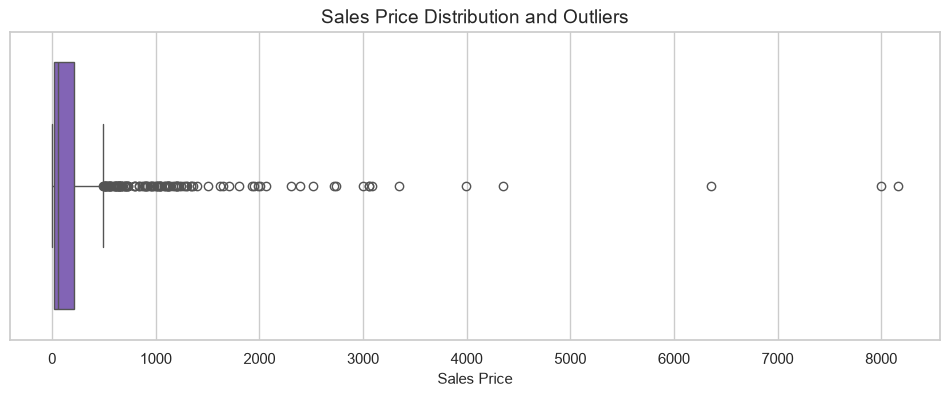

In [149]:
# Create a box plot for Sales Price
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 4))
sns.boxplot(
    data=Clean_Data, 
    x='Sales Price',
    color='#7E57C2'
)
plt.title('Sales Price Distribution and Outliers', fontsize=14)
plt.xlabel('Sales Price', fontsize=11)
plt.show()


In [150]:
# Calculate the IQR boundaries
Q1 = Clean_Data['Sales Price'].quantile(0.25)
Q3 = Clean_Data['Sales Price'].quantile(0.75)
print("Q1:", Q1)
print("Q3:", Q3)

Q1: 18.504
Q3: 207.84600000000003


In [151]:
IQR = Q3 - Q1
Lower_Bound = Q1-(1.5*IQR)
Upper_Bound = Q3+(1.5*IQR)
print("IQR:", IQR)
print("Lower Boundary:", Lower_Bound)
print ("Upper Boundary",Upper_Bound)

IQR: 189.34200000000004
Lower Boundary: -265.509
Upper Boundary 491.85900000000004


In [152]:
print("Number of outliers higher than upper boundary:", (Clean_Data['Sales Price']>Upper_Bound).sum())

Number of outliers higher than upper boundary: 118


In [153]:
# Get all Sales Price outlier rows
sales_price_outliers = Clean_Data[
    (Clean_Data['Sales Price'] > Upper_Bound)
].copy()
print("Number of Outliers:", sales_price_outliers.shape[0])
outlier_percentage = (
    sales_price_outliers.shape[0] / Clean_Data.shape[0]
) * 100
print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Number of Outliers: 118
Outlier Percentage: 11.65%


In [154]:
# Show the top 10 outliers sorted by Sales Price
sales_price_outliers[
    ['Order ID','Product Name','Product Category','Sub-Category','Sales Price','Quantity','Total Sales Amount','Net Profit']
    ].sort_values(by='Sales Price', ascending=False).head(10)

,Order ID,Product Name,Product Category,Sub-Category,Sales Price,Quantity,Total Sales Amount,Net Profit
163,CA-2014-139892,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,8159.952,8.0,65279.6160,22847.8656
672,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,4.0,31999.9200,15999.9600
499,CA-2015-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,6354.950,5.0,31774.7500,11121.1625
348,CA-2016-129714,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,4355.168,4.0,13936.5376,5226.2016
314,CA-2014-164973,Canon imageCLASS MF7460 Monochrome Digital Las...,Technology,Machines,3991.980,2.0,7983.9600,2395.1880
247,CA-2016-145625,Logitech P710e Mobile Speakerphone,Technology,Accessories,3347.370,13.0,43515.8100,19582.1145
27,US-2015-150630,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,3083.430,7.0,21584.0100,6475.2030
965,CA-2017-159366,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,3059.982,2.0,5507.9676,1223.9928
258,US-2014-106992,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,3059.982,3.0,9179.9460,3671.9784
505,CA-2017-127432,Canon Image Class D660 Copier,Technology,Copiers,2999.950,5.0,14999.7500,5249.9125


In [155]:
# مش هعدل حاجة عشان ال Products ديه اسعارها الحقيقية

In [156]:
Clean_Data.describe().T

,count,mean,min,25%,50%,75%,max,std
Year,1013.0,2015.78381,2014.0,2015.0,2016.0,2017.0,2020.0,1.290607
Order Date,1013,2016-04-04 02:02:15.044422,2014-01-04 00:00:00,2015-04-25 00:00:00,2016-05-30 00:00:00,2017-04-07 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,1013,2016-04-08 02:16:27.956564,2014-01-08 00:00:00,2015-04-28 00:00:00,2016-06-04 00:00:00,2017-04-11 00:00:00,2018-01-05 00:00:00,NaN
Postal Code,1013.0,53818.194472,1841.0,19805.0,53132.0,85254.0,98661.0,31657.599812
Sales Price,1013.0,236.395898,1.08,18.504,55.5,207.846,8159.952,593.599176
Quantity,1013.0,3.810464,1.0,2.0,3.0,5.0,14.0,2.269755
Discount,1013.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Total Sales Amount,1013.0,1109.305256,1.68,44.7936,163.44,732.1088,65279.616,3648.500604
Purchasing Price,1013.0,143.390153,0.648,11.0976,33.288,121.47,5303.9688,358.969712
Total Purchasing Amounts,1013.0,719.116463,0.924,29.472,113.568,480.4,42431.7504,2274.609212


### ✅ Handling Quantity Outliers

In [157]:
Q1_quantity = Clean_Data['Quantity'].quantile(0.25)
Q3_quantity = Clean_Data['Quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity
lower_quantity = Q1_quantity - (1.5 * IQR_quantity)
upper_quantity = Q3_quantity + (1.5 * IQR_quantity)
print("Q1:", Q1_quantity)
print("Q3:", Q3_quantity)
print("IQR:", IQR_quantity)
print("Lower Boundary:", lower_quantity)
print("Upper Boundary:", upper_quantity)

Q1: 2.0
Q3: 5.0
IQR: 3.0
Lower Boundary: -2.5
Upper Boundary: 9.5


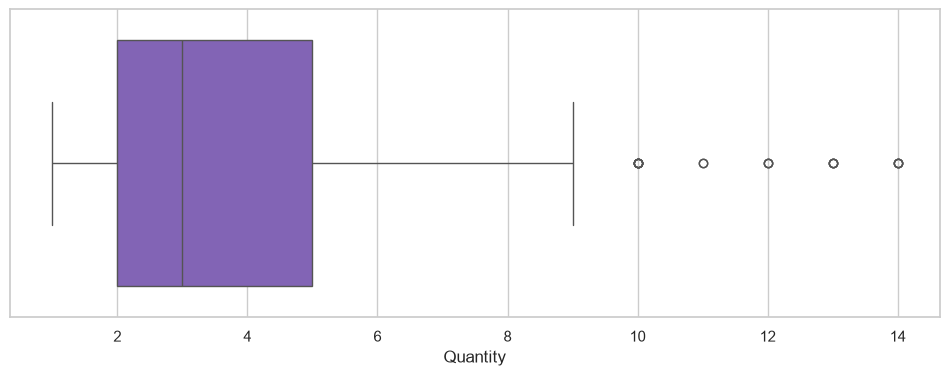

In [158]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=Clean_Data, x='Quantity', color='#7E57C2')
plt.show()

In [159]:
quantity_outliers = Clean_Data[
    (Clean_Data['Quantity'] < lower_quantity) |
    (Clean_Data['Quantity'] > upper_quantity)
].copy()

print("Number of Quantity Outliers:", quantity_outliers.shape[0])

quantity_outlier_percentage = (
    quantity_outliers.shape[0] / Clean_Data.shape[0]
) * 100

print(f"Outlier Percentage: {quantity_outlier_percentage:.2f}%")

Number of Quantity Outliers: 20
Outlier Percentage: 1.97%


In [160]:
quantity_outliers['Quantity'].value_counts().sort_index()

Quantity
10.0    7
11.0    2
12.0    3
13.0    4
14.0    4
Name: count, dtype: int64

In [161]:
quantity_outliers[
    [
        'Order ID',
        'Product Name',
        'Product Category',
        'Quantity',
        'Sales Price',
        'Total Sales Amount'
    ]
].sort_values(
    by='Quantity',
    ascending=False
).head(10)

,Order ID,Product Name,Product Category,Quantity,Sales Price,Total Sales Amount
111,CA-2014-115259,"OIC Colored Binder Clips, Assorted Sizes",Office Supplies,14.0,40.096,449.07520
137,CA-2016-145583,Longer-Life Soft White Bulbs,Furniture,14.0,43.120,603.68000
649,CA-2015-146563,Space Solutions Commercial Steel Shelving,Office Supplies,14.0,724.080,8109.69600
565,CA-2015-149713,Personal Creations Ink Jet Cards and Labels,Office Supplies,14.0,160.720,2250.08000
1001,US-2015-126214,Bevis 36 x 72 Conference Tables,Furniture,13.0,1618.370,21038.81000
247,CA-2016-145625,Logitech P710e Mobile Speakerphone,Technology,13.0,3347.370,43515.81000
404,CA-2017-117457,O'Sullivan 4-Shelf Bookcase in Odessa Pine,Furniture,13.0,1336.829,14771.96045
337,CA-2014-122336,Staples,Office Supplies,13.0,30.992,322.31680
937,US-2017-110576,"Riverside Furniture Oval Coffee Table, Oval En...",Furniture,12.0,2065.320,24783.84000
874,CA-2017-115364,Eldon Shelf Savers Cubes and Bins,Office Supplies,12.0,83.760,1005.12000


## 🧹 Handling Inconsistent Values and Formats

### 📅 Checking Year and Order Date Consistency

We will compare the `Year` column with the year extracted from `Order Date`, then correct any inconsistent values using `Order Date`.

In [162]:
# Convert Order Date to datetime format
Clean_Data['Order Date'] = pd.to_datetime(
    Clean_Data['Order Date'],
    errors='coerce'
)

In [163]:
# Verify that converting Order Date did not create missing values
print("Invalid Order Dates:", Clean_Data['Order Date'].isnull().sum())

Invalid Order Dates: 0


In [164]:
# Extract the correct year from Order Date and find mismatches
year_from_order_date = Clean_Data['Order Date'].dt.year
year_mismatch = Clean_Data['Year'] != year_from_order_date

print("Year Mismatches:", year_mismatch.sum())

Year Mismatches: 26


In [165]:
# Preview rows where Year disagrees with Order Date
Clean_Data.loc[
    year_mismatch,
    ['Order ID', 'Year', 'Order Date']
].assign(
    Correct_Year=year_from_order_date[year_mismatch]
).head(10)

,Order ID,Year,Order Date,Correct_Year
0,CA-2016-152156,2020.0,2016-11-08,2016
1,CA-2016-152156,2020.0,2016-11-08,2016
2,CA-2016-138688,2020.0,2016-06-12,2016
3,US-2015-108966,2020.0,2015-10-11,2015
4,US-2015-108966,2020.0,2015-10-11,2015
5,CA-2014-115812,2020.0,2014-06-09,2014
6,CA-2014-115812,2020.0,2014-06-09,2014
7,CA-2014-115812,2020.0,2014-06-09,2014
8,CA-2014-115812,2020.0,2014-06-09,2014
9,CA-2014-115812,2020.0,2014-06-09,2014


In [166]:
# Correct Year using the trusted Order Date column
Clean_Data['Year'] = Clean_Data['Order Date'].dt.year

In [167]:
# Confirm that all Year values now match Order Date
year_mismatch_after = (
    Clean_Data['Year'] != Clean_Data['Order Date'].dt.year
).sum()

print("Year Mismatches After Cleaning:", year_mismatch_after)

Year Mismatches After Cleaning: 0


### 🔁 Detecting Duplicate Records

In [168]:
# Count completely duplicated rows
duplicate_count = Clean_Data.duplicated().sum()
print("Number of Complete Duplicates:", duplicate_count)

Number of Complete Duplicates: 7


In [169]:
# Find all rows participating in complete duplicates
duplicate_mask = Clean_Data.duplicated(keep=False)

# Select the duplicated rows
duplicate_rows = Clean_Data[duplicate_mask]

# Sort them so every duplicate appears beside its matching row
duplicate_rows = duplicate_rows.sort_values(
    by=['Order ID', 'Product ID']
)

print("Rows Participating in Duplicates:", duplicate_rows.shape[0])

duplicate_rows

Rows Participating in Duplicates: 14


,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
706,CA-2014-104472,2014,Jun,2014-06-02,2014-06-07,Standard Class,CK-12325,Christine Kargatis,Home Office,United States,...,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,59.808,3.0,0.0,143.5392,41.8656,125.5968,17.9424
1011,CA-2014-104472,2014,Jun,2014-06-02,2014-06-07,Standard Class,CK-12325,Christine Kargatis,Home Office,United States,...,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,59.808,3.0,0.0,143.5392,41.8656,125.5968,17.9424
179,CA-2014-158274,2014,Nov,2014-11-19,2014-11-24,Second Class,RM-19675,Robert Marley,Home Office,United States,...,Technology,Phones,Nokia Lumia 521 (T-Mobile),149.950,5.0,0.0,749.7500,74.9750,374.8750,374.8750
1008,CA-2014-158274,2014,Nov,2014-11-19,2014-11-24,Second Class,RM-19675,Robert Marley,Home Office,United States,...,Technology,Phones,Nokia Lumia 521 (T-Mobile),149.950,5.0,0.0,749.7500,74.9750,374.8750,374.8750
998,CA-2014-158540,2014,Nov,2014-11-24,2014-11-26,First Class,VG-21790,Vivek Gonzalez,Consumer,United States,...,Furniture,Furnishings,"Eldon Delta Triangular Chair Mat, 52"" x 58"", C...",151.720,4.0,0.0,606.8800,91.0320,364.1280,242.7520
1013,CA-2014-158540,2014,Nov,2014-11-24,2014-11-26,First Class,VG-21790,Vivek Gonzalez,Consumer,United States,...,Furniture,Furnishings,"Eldon Delta Triangular Chair Mat, 52"" x 58"", C...",151.720,4.0,0.0,606.8800,91.0320,364.1280,242.7520
873,CA-2015-143602,2015,Apr,2015-04-25,2015-04-28,Second Class,JS-15595,Jill Stevenson,Corporate,United States,...,Office Supplies,Binders,Fellowes Black Plastic Comb Bindings,13.944,3.0,0.0,33.4656,9.0636,27.1908,6.2748
1012,CA-2015-143602,2015,Apr,2015-04-25,2015-04-28,Second Class,JS-15595,Jill Stevenson,Corporate,United States,...,Office Supplies,Binders,Fellowes Black Plastic Comb Bindings,13.944,3.0,0.0,33.4656,9.0636,27.1908,6.2748
40,CA-2017-120999,2017,Sep,2017-09-10,2017-09-15,Standard Class,LC-16930,Linda Cazamias,Corporate,United States,...,Technology,Phones,Panasonic Kx-TS550,147.168,4.0,0.0,470.9376,80.9424,323.7696,147.1680
1007,CA-2017-120999,2017,Sep,2017-09-10,2017-09-15,Standard Class,LC-16930,Linda Cazamias,Corporate,United States,...,Technology,Phones,Panasonic Kx-TS550,147.168,4.0,0.0,470.9376,80.9424,323.7696,147.1680


### 🗑️ Removing Exact Duplicate Rows

Keep the first occurrence of every completely identical row and remove only the extra copies.

In [170]:
# Save the row count before removing duplicates
rows_before_duplicates = Clean_Data.shape[0]

# Keep the first copy and remove only the extra identical rows
Clean_Data = Clean_Data.drop_duplicates(keep='first').reset_index(drop=True)

# Calculate how many rows were removed
rows_after_duplicates = Clean_Data.shape[0]
removed_duplicates = rows_before_duplicates - rows_after_duplicates

print("Rows Before Removing Duplicates:", rows_before_duplicates)
print("Removed Duplicate Rows:", removed_duplicates)
print("Rows After Removing Duplicates:", rows_after_duplicates)

Rows Before Removing Duplicates: 1013
Removed Duplicate Rows: 7
Rows After Removing Duplicates: 1006


In [171]:
# Final validation for missing values and complete duplicates
remaining_missing_values = Clean_Data.isnull().sum().sum()
remaining_duplicates = Clean_Data.duplicated().sum()
print("Remaining Missing Values:", remaining_missing_values)
print("Remaining Complete Duplicates:", remaining_duplicates)
assert remaining_missing_values == 0, "Missing values still exist."
assert remaining_duplicates == 0, "Duplicate rows still exist."
print("Cleaning validation passed successfully.")

Remaining Missing Values: 0
Remaining Complete Duplicates: 0
Cleaning validation passed successfully.


## ⚙️ 3. Feature Engineering

### 💹 Creating Profit Margin|

In [172]:
Clean_Data['Profit Margin (%)'] = (Clean_Data['Net Profit']/Clean_Data['Total Sales Amount'] * 100).round(2)

In [173]:
Clean_Data['Profit Margin (%)'].head(10)

0    40.0
1    45.0
2    40.0
3    50.0
4    37.5
5    35.0
6    40.0
7    12.5
8    12.5
9    35.0
Name: Profit Margin (%), dtype: float64

In [174]:
Clean_Data[['Total Sales Amount','Net Profit','Profit Margin (%)']].head(10)

,Total Sales Amount,Net Profit,Profit Margin (%)
0,523.9200,209.56800,40.0
1,2195.8200,988.11900,45.0
2,29.2400,11.69600,40.0
3,4787.8875,2393.94375,50.0
4,35.7888,13.42080,37.5
5,342.0200,119.70700,35.0
6,29.1200,11.64800,40.0
7,4354.3296,544.29120,12.5
8,44.4096,5.55120,12.5
9,574.5000,201.07500,35.0


### 🚚 Creating Shipping Duration

In [175]:
Clean_Data.head(5)

,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit,Profit Margin (%)
0,CA-2016-152156,2016,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.0,523.9200,157.17600,314.35200,209.56800,40.0
1,CA-2016-152156,2016,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.0,2195.8200,402.56700,1207.70100,988.11900,45.0
2,CA-2016-138688,2016,Jun,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.0,29.2400,8.77200,17.54400,11.69600,40.0
3,US-2015-108966,2015,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.0,4787.8875,478.78875,2393.94375,2393.94375,50.0
4,US-2015-108966,2015,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.0,35.7888,11.18400,22.36800,13.42080,37.5


In [176]:
Clean_Data['Ship Date'] = pd.to_datetime(
    Clean_Data['Ship Date'], errors='coerce'       
)
Clean_Data['Ship Date'].dtype

dtype('<M8[us]')

In [177]:
Clean_Data['Ship Duration (Days)'] = (Clean_Data['Ship Date'] - Clean_Data['Order Date']).dt.days

In [178]:
# Preview the new column
Clean_Data[
    ['Order Date', 'Ship Date', 'Ship Duration (Days)']
].head()

,Order Date,Ship Date,Ship Duration (Days)
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


### 📊 Creating Sales Performance Category

In [179]:
Clean_Data['Sales Performance Category']= pd.qcut(
    Clean_Data['Total Sales Amount'],q=3 ,labels=['Low Sales' , 'Medium Sales' , 'High Sales']
    )                                                

In [180]:
# Preview the new category
Clean_Data[
    ['Total Sales Amount', 'Sales Performance Category']
].head(10)

,Total Sales Amount,Sales Performance Category
0,523.9200,High Sales
1,2195.8200,High Sales
2,29.2400,Low Sales
3,4787.8875,High Sales
4,35.7888,Low Sales
5,342.0200,Medium Sales
6,29.1200,Low Sales
7,4354.3296,High Sales
8,44.4096,Low Sales
9,574.5000,High Sales


## 🧩 4. Modular Analytical Functions

### 📌 Creating a KPI Summary Function

In [181]:
def calculate_total_sales(df):
    total_sales = df['Total Sales Amount'].sum()
    return total_sales

In [182]:
calculate_total_sales(Clean_Data)

np.float64(1116515.01204)

In [183]:
def calculate_total_profit(df):
    total_profit = df['Net Profit'].sum()
    return total_profit

In [184]:
calculate_total_profit(Clean_Data)

np.float64(392651.10763000004)

In [185]:
def calculate_overall_profit_margin(df):
    total_sales = calculate_total_sales(df)
    total_profit = calculate_total_profit(df)

    profit_margin = (
        total_profit / total_sales
    ) * 100

    return profit_margin

In [186]:
round(
    calculate_overall_profit_margin(Clean_Data),
    2
)

np.float64(35.17)

## 🔍 5. Exploratory Data Analysis (EDA)

### 🗂️ Sales and Profit by Product Category

In [187]:
category_performance = Clean_Data.groupby(
    'Product Category'
).agg(
    Total_Sales=('Total Sales Amount', 'sum'),
    Total_Profit=('Net Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Orders=('Order ID', 'nunique')
).sort_values(
    by='Total_Sales',
    ascending=False
)

category_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Product Category,,,,
Technology,462915.90,170710.67,749.0,161
Furniture,350229.84,113917.38,792.0,170
Office Supplies,303369.26,108023.06,2290.0,369


### 🌍 Sales and Profit by Region

Compare regional sales, profit, order count, and overall profit margin.

In [188]:
# Summarize business performance for each region
region_performance = Clean_Data.groupby('Region').agg(
    Total_Sales=('Total Sales Amount', 'sum'),
    Total_Profit=('Net Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Orders=('Order ID', 'nunique')
)

# Calculate each region's overall profit margin
region_performance['Profit_Margin_Percent'] = (
    region_performance['Total_Profit']
    / region_performance['Total_Sales']
    * 100
)

region_performance = region_performance.sort_values(
    by='Total_Sales',
    ascending=False
)

region_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_Percent
Region,,,,,
West,341156.92,117765.99,1179.0,152,34.52
Central,308258.67,104220.42,936.0,121,33.81
East,286321.21,101025.00,1253.0,137,35.28
South,180778.22,69639.70,463.0,78,38.52


### 👥 Sales and Profit by Customer Segment

Compare Consumer, Corporate, and Home Office customer segments.

In [189]:
# Summarize business performance for each customer segment
segment_performance = Clean_Data.groupby('Client Segment').agg(
    Total_Sales=('Total Sales Amount', 'sum'),
    Total_Profit=('Net Profit', 'sum'),
    Number_of_Customers=('Customer ID', 'nunique'),
    Number_of_Orders=('Order ID', 'nunique')
)

segment_performance['Profit_Margin_Percent'] = (
    segment_performance['Total_Profit']
    / segment_performance['Total_Sales']
    * 100
)

segment_performance = segment_performance.sort_values(
    by='Total_Sales',
    ascending=False
)

segment_performance.round(2)

,Total_Sales,Total_Profit,Number_of_Customers,Number_of_Orders,Profit_Margin_Percent
Client Segment,,,,,
Consumer,591565.41,202934.78,195,264,34.30
Corporate,305427.90,114791.07,111,149,37.58
Home Office,219521.70,74925.26,60,75,34.13


### 📅 Yearly Sales and Profit Trend

Track annual performance and calculate year-over-year sales growth.

In [190]:
# Aggregate sales, profit, and orders by year
yearly_performance = Clean_Data.groupby('Year').agg(
    Total_Sales=('Total Sales Amount', 'sum'),
    Total_Profit=('Net Profit', 'sum'),
    Number_of_Orders=('Order ID', 'nunique')
).sort_index()

# Calculate overall margin and year-over-year sales growth
yearly_performance['Profit_Margin_Percent'] = (
    yearly_performance['Total_Profit']
    / yearly_performance['Total_Sales']
    * 100
)
yearly_performance['Sales_Growth_Percent'] = (
    yearly_performance['Total_Sales'].pct_change()
    * 100
)

yearly_performance.round(2)

,Total_Sales,Total_Profit,Number_of_Orders,Profit_Margin_Percent,Sales_Growth_Percent
Year,,,,,
2014,323177.92,108999.60,100,33.73,NaN
2015,255589.37,90329.20,102,35.34,-20.91
2016,286503.79,102445.66,135,35.76,12.10
2017,251243.93,90876.64,151,36.17,-12.31


### 🏆 Top 10 Products by Sales

Identify the products generating the highest total sales.

In [191]:
# Calculate product-level sales and profit, then keep the top 10
top_products = (
    Clean_Data.groupby(['Product ID', 'Product Name'])
    .agg(
        Total_Sales=('Total Sales Amount', 'sum'),
        Total_Profit=('Net Profit', 'sum'),
        Total_Quantity=('Quantity', 'sum')
    )
    .sort_values(by='Total_Sales', ascending=False)
    .head(10)
)

top_products.round(2)

,,Total_Sales,Total_Profit,Total_Quantity
Product ID,Product Name,,,
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,79967.53,27743.84,13.0
TEC-AC-10003832,Logitech P710e Mobile Speakerphone,44998.95,19860.20,16.0
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,31999.92,15999.96,4.0
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,31774.75,11121.16,5.0
FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",28101.85,6762.75,11.0
FUR-TA-10004154,"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",24783.84,8674.34,12.0
FUR-TA-10003748,Bevis 36 x 72 Conference Tables,24151.06,11764.30,18.0
OFF-BI-10003925,Fellowes PB300 Plastic Comb Binding Machine,19011.51,9505.76,7.0
FUR-TA-10002903,"Bevis Round Bullnose 29"" High Table Top",18283.58,6690.13,17.0


## 📐 6. Statistical Analysis

### 🔗 Correlation Analysis

Correlation measures the strength and direction of the relationship between numerical variables, using values from `-1` to `1`.

In [192]:
# Select the numerical columns used in the analysis
correlation_columns = [
    'Sales Price',
    'Quantity',
    'Total Sales Amount',
    'Net Profit',
    'Profit Margin (%)',
    'Ship Duration (Days)'
]

# Calculate the correlation matrix
correlation_matrix = Clean_Data[correlation_columns].corr()

correlation_matrix.round(2)

,Sales Price,Quantity,Total Sales Amount,Net Profit,Profit Margin (%),Ship Duration (Days)
Sales Price,1.00,0.21,0.89,0.85,0.00,-0.06
Quantity,0.21,1.00,0.35,0.33,-0.01,0.02
Total Sales Amount,0.89,0.35,1.00,0.97,0.05,-0.03
Net Profit,0.85,0.33,0.97,1.00,0.13,-0.03
Profit Margin (%),0.00,-0.01,0.05,0.13,1.00,-0.04
Ship Duration (Days),-0.06,0.02,-0.03,-0.03,-0.04,1.00


### 🌡️ Correlation Heatmap

The heatmap makes strong positive and negative relationships easier to identify visually.

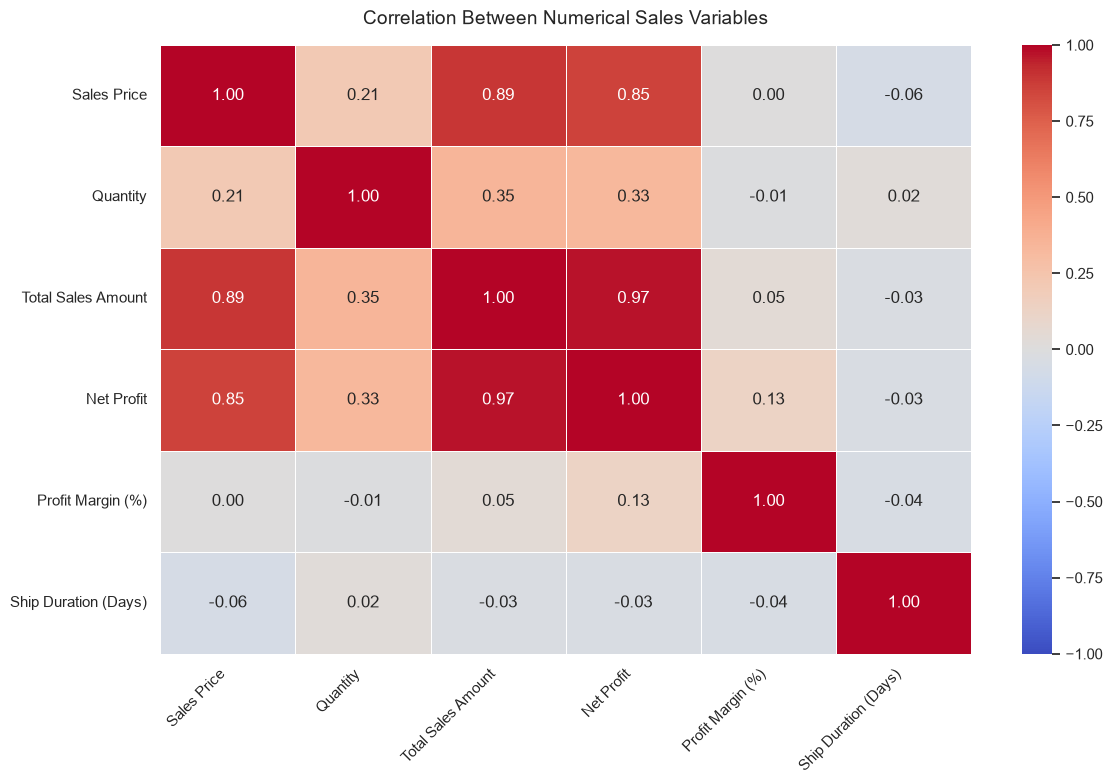

In [193]:
# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Correlation Between Numerical Sales Variables', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Reading the Correlation Results

- Total sales and net profit have a strong positive relationship.
- Shipping duration has almost no relationship with sales or profit.
- Correlation shows a relationship, but it does not prove that one variable causes another.

## 📊 7. Data Visualizations

These charts compare sales, profit, customers, products, time trends, and distributions.

### 1. Total Sales by Product Category

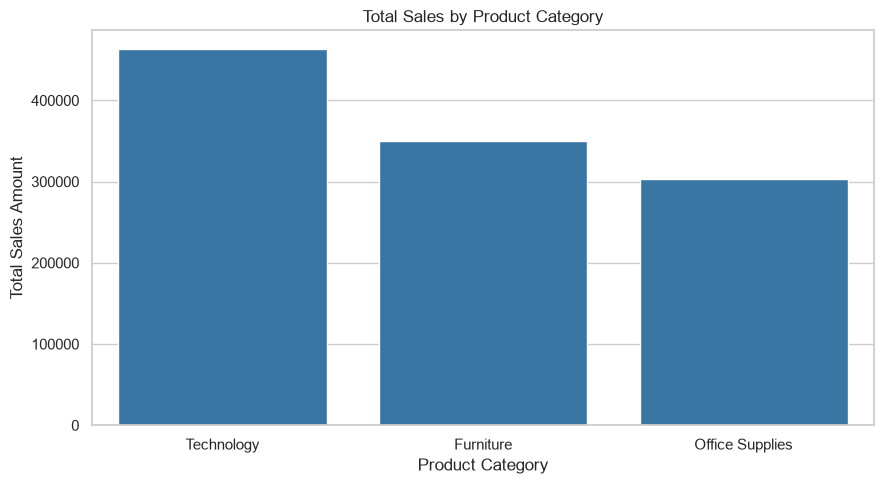

In [194]:
sales_by_category = category_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=sales_by_category,
    x='Product Category',
    y='Total_Sales',
    color='#2878B5'
)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### 2. Total Profit by Region

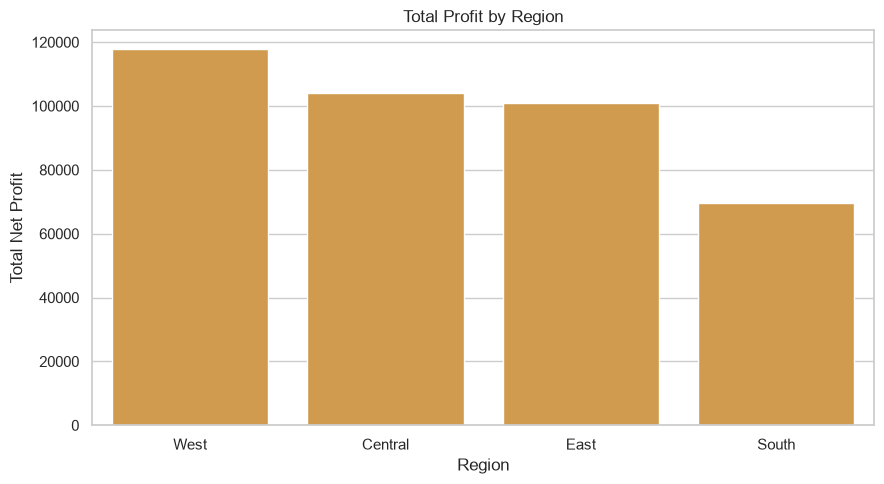

In [195]:
profit_by_region = region_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=profit_by_region,
    x='Region',
    y='Total_Profit',
    color='#E59F3A'
)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Net Profit')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### 3. Total Sales by Customer Segment

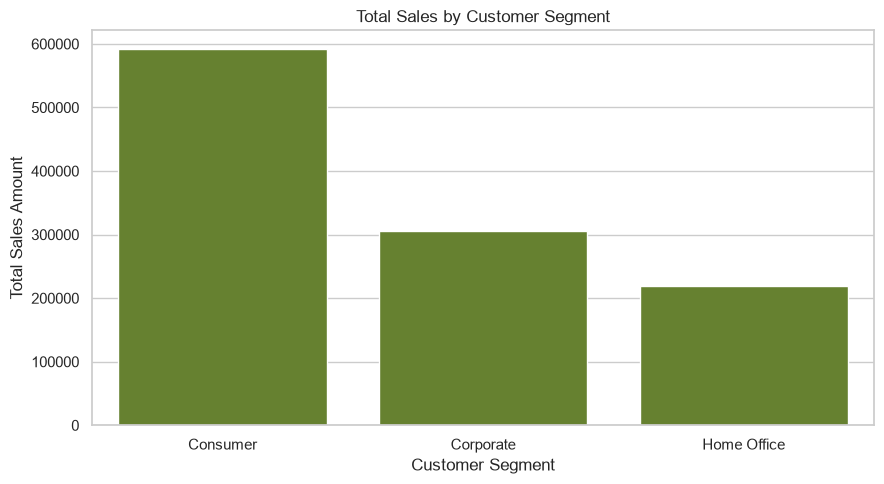

In [196]:
sales_by_segment = segment_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=sales_by_segment,
    x='Client Segment',
    y='Total_Sales',
    color='#6B8E23'
)
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

### 4. Total Sales by Year

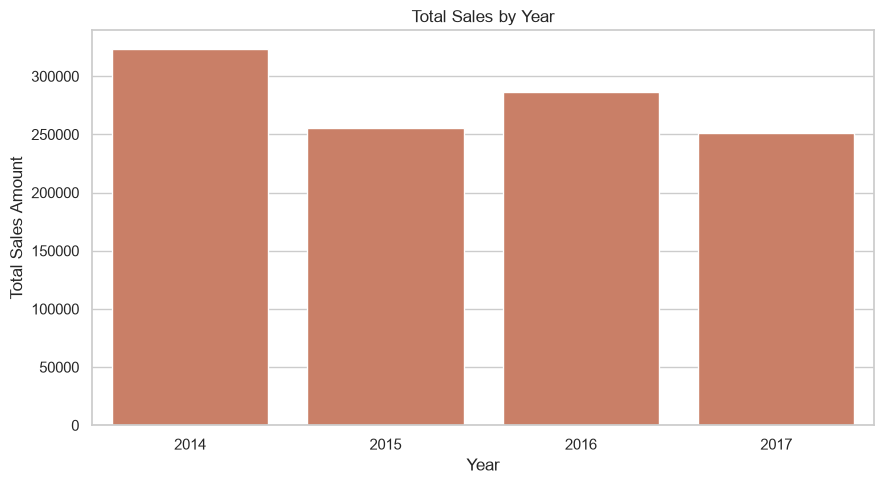

In [197]:
sales_by_year = yearly_performance.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=sales_by_year,
    x='Year',
    y='Total_Sales',
    color='#D97757'
)
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

### 5. Monthly Sales Trend

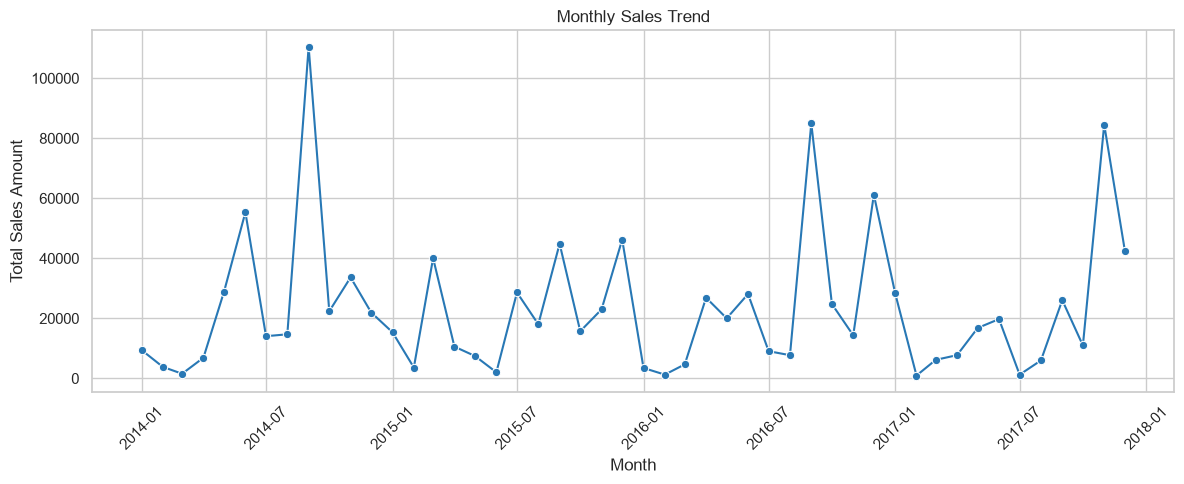

In [198]:
# Calculate total sales for every month in chronological order
monthly_sales = (
    Clean_Data.groupby(
        Clean_Data['Order Date'].dt.to_period('M')
    )['Total Sales Amount']
    .sum()
    .reset_index()
)

# Convert Year-Month back to a date so the chart stays in the correct order
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_sales,
    x='Order Date',
    y='Total Sales Amount',
    marker='o',
    color='#2878B5'
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Top 10 Products by Sales

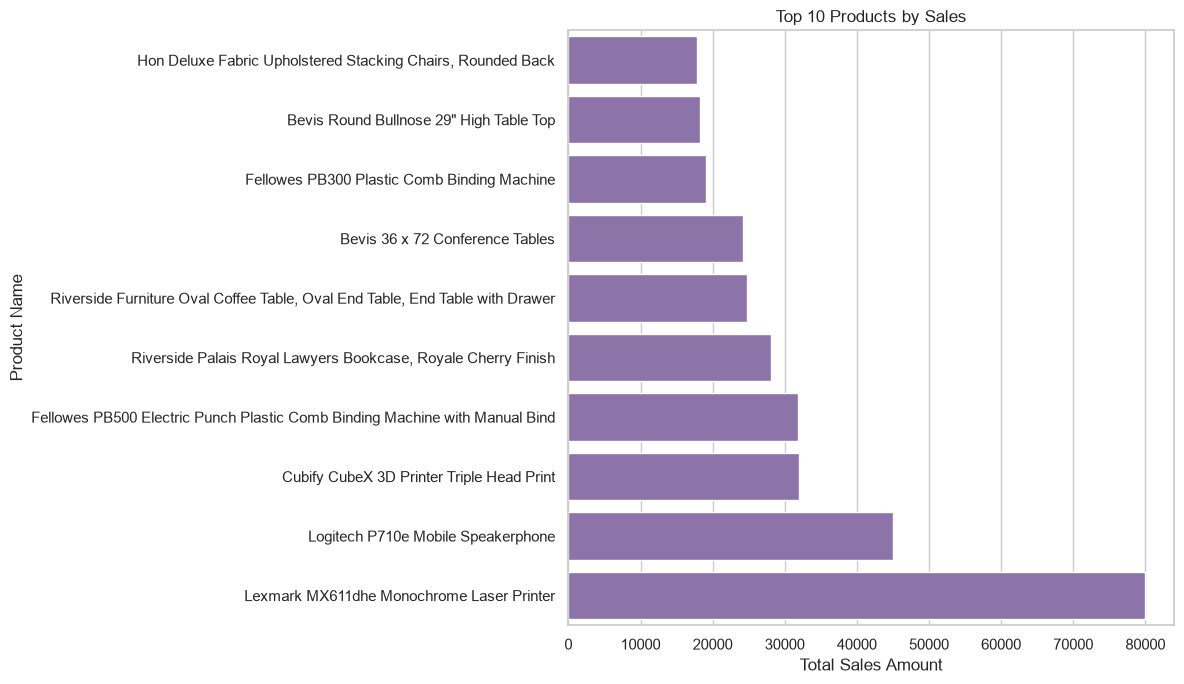

In [199]:
top_products_chart = top_products.reset_index()
top_products_chart = top_products_chart.sort_values(
    by='Total_Sales',
    ascending=True
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_products_chart,
    x='Total_Sales',
    y='Product Name',
    color='#8B6BB1'
)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales Amount')
plt.ylabel('Product Name')
plt.xlim(left=0)
plt.tight_layout()
plt.show()

### 7. Distribution of Total Sales Amount

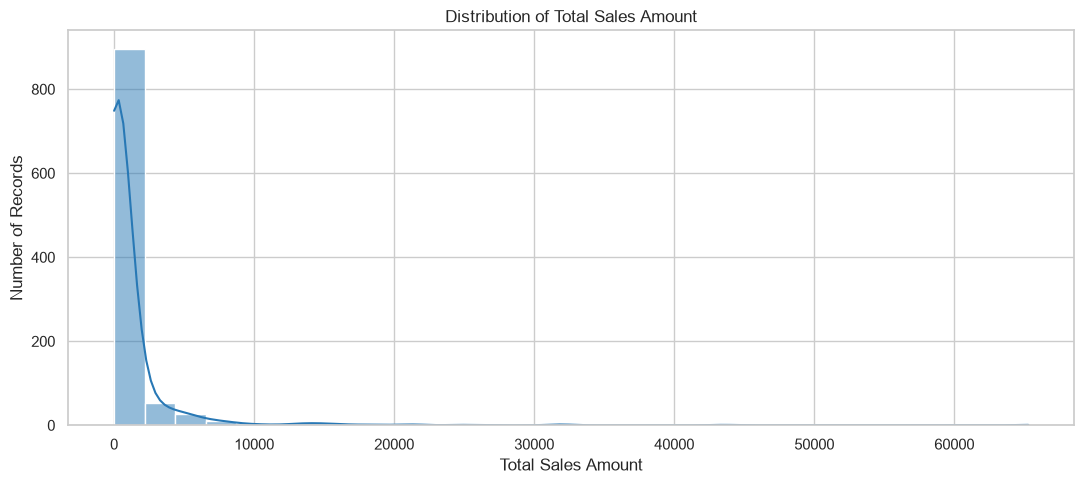

In [200]:
plt.figure(figsize=(11, 5))
sns.histplot(
    data=Clean_Data,
    x='Total Sales Amount',
    bins=30,
    kde=True,
    color='#2878B5'
)
plt.title('Distribution of Total Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

### 8. Shipping Duration Distribution

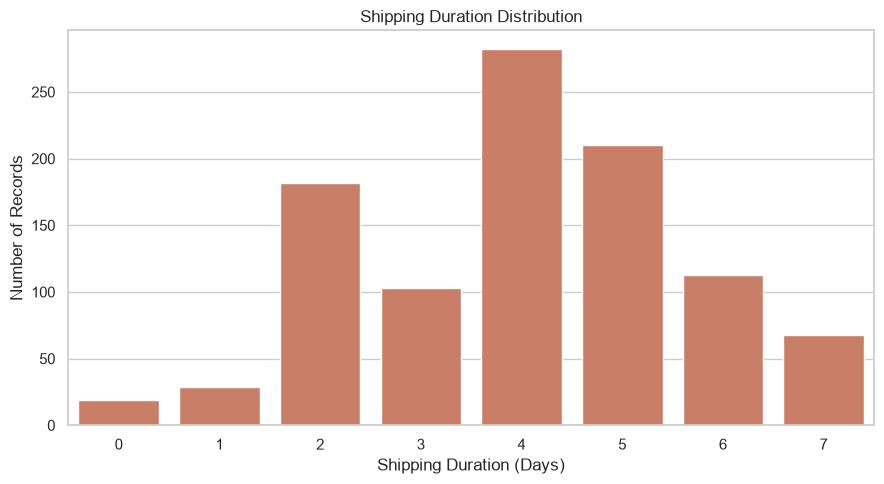

In [201]:
shipping_days = (
    Clean_Data['Ship Duration (Days)']
    .value_counts()
    .sort_index()
    .reset_index()
)
shipping_days.columns = ['Shipping Days', 'Number of Records']

plt.figure(figsize=(9, 5))
sns.barplot(
    data=shipping_days,
    x='Shipping Days',
    y='Number of Records',
    color='#D97757'
)
plt.title('Shipping Duration Distribution')
plt.xlabel('Shipping Duration (Days)')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

## 🔄 8. Simple Reusable Preprocessing Function

This small function keeps the main preparation steps reusable without changing the original DataFrame.

In [202]:
def prepare_sales_data(df):
    prepared_df = df.copy()

    prepared_df = prepared_df.dropna(how='all')

    prepared_df['Order Date'] = pd.to_datetime(
        prepared_df['Order Date'],
        errors='coerce'
    )
    prepared_df['Ship Date'] = pd.to_datetime(
        prepared_df['Ship Date'],
        errors='coerce'
    )

    prepared_df['Year'] = prepared_df['Order Date'].dt.year
    prepared_df['Month'] = prepared_df['Order Date'].dt.strftime('%b')

    prepared_df = prepared_df.drop_duplicates()
    prepared_df = prepared_df.reset_index(drop=True)

    return prepared_df

In [203]:
prepared_data = prepare_sales_data(Clean_Data)

print("Rows after preparation:", prepared_data.shape[0])
print("Columns after preparation:", prepared_data.shape[1])

Rows after preparation: 1006
Columns after preparation: 27


## 🧩 9. Simple Object-Oriented Programming Example

The class stores the sales data and creates an automatic KPI summary.

In [204]:
class SalesReport:
    def __init__(self, data):
        self.data = data
    def create_kpi_summary(self):
        total_sales = self.data['Total Sales Amount'].sum()
        total_profit = self.data['Net Profit'].sum()
        profit_margin = total_profit / total_sales * 100
        summary = {
            'KPI': [
                'Total Sales',
                'Total Net Profit',
                'Overall Profit Margin (%)',
                'Number of Orders',
                'Number of Customers',
                'Average Shipping Days'
            ],
            'Value': [
                round(total_sales, 2),
                round(total_profit, 2),
                round(profit_margin, 2),
                self.data['Order ID'].nunique(),
                self.data['Customer ID'].nunique(),
                round(self.data['Ship Duration (Days)'].mean(), 2)
            ]
        }
        return pd.DataFrame(summary)

In [205]:
sales_report = SalesReport(Clean_Data)
kpi_summary = sales_report.create_kpi_summary()
kpi_summary

,KPI,Value
0,Total Sales,1116515.01
1,Total Net Profit,392651.11
2,Overall Profit Margin (%),35.17
3,Number of Orders,488.00
4,Number of Customers,366.00
5,Average Shipping Days,4.01


## ⚡ 10. Memory Usage Optimization

Repeated text columns are converted to the `category` type to reduce memory usage.

In [206]:
memory_before = Clean_Data.memory_usage(deep=True).sum() / 1024**2
category_columns = [
    'Ship Mode',
    'Client Segment',
    'Country',
    'Region',
    'Product Category',
    'Sub-Category',
    'Sales Performance Category'
]
for column in category_columns:
    Clean_Data[column] = Clean_Data[column].astype('category')
memory_after = Clean_Data.memory_usage(deep=True).sum() / 1024**2
memory_saved = memory_before - memory_after
print("Memory before:", round(memory_before, 3), "MB")
print("Memory after:", round(memory_after, 3), "MB")
print("Memory saved:", round(memory_saved, 3), "MB")

Memory before: 0.865 MB
Memory after: 0.533 MB
Memory saved: 0.332 MB


## 📝 11. Main Findings

- Total sales reached about **1,116,515**, with total net profit of about **392,651**.
- The overall profit margin was approximately **35.17%**.
- **Technology** generated the highest sales and profit among product categories.
- The **West** region generated the highest sales, while the **South** had the highest profit margin.
- The **Consumer** segment generated the highest sales, while **Corporate** had the highest profit margin.
- Sales decreased in 2015, recovered in 2016, and decreased again in 2017.
- High-value outliers were kept because they represent valid expensive products rather than data-entry errors.
- The source `Discount` column contains only zero values, so discount behavior was not included in the analysis.
